In [180]:
# library imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.keras
from sklearn.preprocessing import MinMaxScaler
sns.set_style("darkgrid")

In [181]:
# check the gpu
devices = tf.config.list_physical_devices()
print("Devices found:", devices)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("Success! GPU is active.")
    # This line tells TF to use the GPU specifically
    tf.config.set_visible_devices(gpu_devices[0], 'GPU')
else:
    print("GPU still not found. You might be running an Intel version of Python.")
import pandas as pd

Devices found: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Success! GPU is active.


In [182]:
f = pd.read_parquet('/Users/faizshaikh/Documents/MATLAB/transmission_system/Training_Dataset.parquet')
print(f.head())

                                       TransientData  FaultID  Interface
0  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...  Fault01       30.0
1  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...  Fault01       60.0
2  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...  Fault01       90.0
3  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...  Fault01       30.0
4  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...  Fault01       60.0


In [183]:
# update the fault IDs to class
mapping = {
    'LG': ['Fault01', 'Fault02', 'Fault03', 'Fault12', 'Fault13', 'Fault14', 
           'Fault23', 'Fault24', 'Fault25', 'Fault34', 'Fault35', 'Fault36'],
    'LL': ['Fault04', 'Fault05', 'Fault06', 'Fault15', 'Fault16', 'Fault17', 
           'Fault26', 'Fault27', 'Fault28', 'Fault37', 'Fault38', 'Fault39'],
    'LLG': ['Fault07', 'Fault08', 'Fault09', 'Fault18', 'Fault19', 'Fault20', 
            'Fault29', 'Fault30', 'Fault31', 'Fault40', 'Fault41', 'Fault42'],
    'LLL': ['Fault10', 'Fault21', 'Fault32', 'Fault43'],
    'LLLG': ['Fault11', 'Fault22', 'Fault33', 'Fault44'],
}

reverse_map = {fault: label for label, faults in mapping.items() for fault in faults}

f.loc[0:1187, 'FaultID'] = f.loc[0:1187, 'FaultID'].map(reverse_map)

# update rows 298 to 594
f.loc[298:594, 'Interface'] += 100

# update rows 595 to 891
f.loc[595:891, 'Interface'] += 200

# update rows 892 to 1188
f.loc[892:1188, 'Interface'] += 300

f = f.rename(columns={'FaultID': 'Fault Type', 'Interface': 'Distance'})

print(f.head())

                                       TransientData Fault Type  Distance
0  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...         LG      30.0
1  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...         LG      60.0
2  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...         LG      90.0
3  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...         LG      30.0
4  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...         LG      60.0


In [184]:
f["Fault Type"].value_counts()

Fault Type
NoFault    594
LG         324
LL         324
LLG        324
LLL        108
LLLG       108
Name: count, dtype: int64

<Axes: xlabel='Fault Type', ylabel='count'>

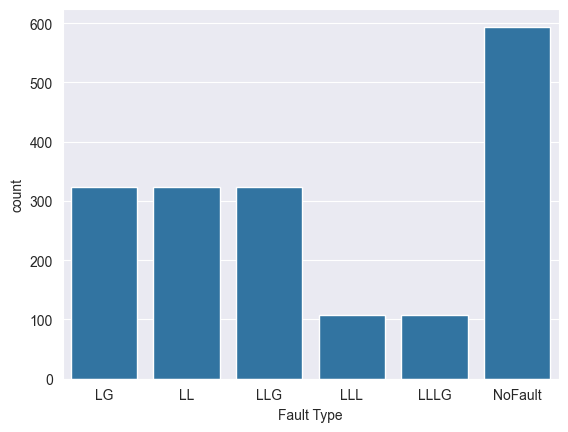

In [185]:
sns.countplot(x=f['Fault Type'])

In [186]:
le = LabelEncoder()
f['Fault Type'] = le.fit_transform(f['Fault Type'])

print(f.head())

                                       TransientData  Fault Type  Distance
0  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...           0      30.0
1  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...           0      60.0
2  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...           0      90.0
3  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...           0      30.0
4  [{'Va': 0.0, 'Vb': 0.0, 'Vc': 0.0, 'Ia': 0.0, ...           0      60.0


In [187]:
# This iterates through every simulation, expands the dictionaries, and stacks them
X = np.array([pd.DataFrame.from_records(sim).values for sim in f['TransientData']])

features = ['Fault Type', 'Distance']
y = f[features].to_numpy()

print({X.shape}) 
print({y.shape})

{(1782, 321, 6)}
{(1782, 2)}


In [188]:
# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

# 1. Create the scaler
scaler_X = MinMaxScaler()

# 2. Flatten 3D to 2D to "teach" the scaler the Min/Max of each of the 6 sensors
# We reshape to (-1, 6) which means "all time steps and samples combined"
X_train_reshaped = X_train.reshape(-1, 6)
scaler_X.fit(X_train_reshaped)

# 3. Transform Train, Val, and Test
X_train_scaled = scaler_X.transform(X_train_reshaped).reshape(X_train.shape)
X_val_scaled = scaler_X.transform(X_val.reshape(-1, 6)).reshape(X_val.shape)
X_test_scaled = scaler_X.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)

scaler_y = MinMaxScaler()

y_test_class = y_test[:, 0]
y_test_dist = y_test[:, 1].reshape(-1, 1)
scaler_y.fit(y_test_dist)
y_test_dist_scaled = scaler_y.transform(y_test_dist)

y_val_class = y_val[:, 0]
y_val_dist_scaled = scaler_y.transform(y_val[:, 1].reshape(-1, 1))

y_train_class = y_train[:, 0]
y_train_dist_scaled = scaler_y.transform(y_train[:, 1].reshape(-1, 1))

# only one-hot encode the CLASS
y_test_cat = tf.keras.utils.to_categorical(y_test_class)
y_val_cat = tf.keras.utils.to_categorical(y_val_class)
y_train_cat = tf.keras.utils.to_categorical(y_train_class)

y_test_final = np.hstack((y_test_cat, y_test_dist_scaled))
y_val_final = np.hstack((y_val_cat, y_val_dist_scaled))
y_train_final = np.hstack((y_train_cat, y_train_dist_scaled))

print(X_test_scaled.shape, X_val_scaled.shape, X_train_scaled.shape)
print(y_test_final.shape, y_val_final.shape, y_train_final.shape)

(223, 321, 6) (223, 321, 6) (1336, 321, 6)
(223, 7) (223, 7) (1336, 7)


In [189]:
# Define the input shape (one sample: 321 time steps, 6 sensors)
inputs = layers.Input(shape=(321, 6))

# --- Shared Feature Extraction (The "Brain") ---
x = layers.Conv1D(64, 5, activation='relu')(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(128, 3, activation='relu')(x)
x = layers.GlobalAveragePooling1D()(x) 
x = layers.Dense(64, activation='relu')(x)

# --- Branch 1: Fault Type (Classification) ---
# Softmax gives us probabilities for each of the 6 classes
type_output = layers.Dense(6, activation='softmax', name='type')(x)

# --- Branch 2: Fault Distance (Regression) ---
# Linear gives us the raw scaled distance value
dist_output = layers.Dense(1, activation='linear', name='distance')(x)

# Define the model with 1 input and 2 outputs
model = Model(inputs=inputs, outputs=[type_output, dist_output])

# Compile with specialized losses for each task
model.compile(
    optimizer='adam', 
    loss={'type': 'categorical_crossentropy', 'distance': 'mse'},
    metrics={'type': 'accuracy', 'distance': 'mae'}
)

In [190]:
print(model.summary())

Model: "functional_57"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 321, 6)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 317, 64)   │      1,984 │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_15    │ (None, 158, 64)   │          0 │ conv1d_20[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 156, 128)  │     24,704 │ max_pooling1d_15… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ conv1d_21[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type (Dense)        │ (None, 6)         │        390 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance (Dense)    │ (None, 1)         │         65 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,399 (138.28 KB)

 Trainable params: 35,399 (138.28 KB)

 Non-trainable params: 0 (0.00 B)

None


In [191]:
model.compile(
    optimizer='adam', 
    loss={'type': 'categorical_crossentropy', 'distance': 'mse'},
    metrics={'type': 'accuracy', 'distance': 'mae'}
)
# Assuming y_train_cat is (Samples, 6) and y_train_dist_scaled is (Samples, 1)
history = model.fit(
    X_train_scaled, 
    {'type': y_train_cat, 'distance': y_train_dist_scaled}, 
    epochs=100, 
    batch_size=32,
    validation_data=(X_val_scaled, {'type': y_val_cat, 'distance': y_val_dist_scaled})
)

Epoch 1/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - distance_loss: 0.1268 - distance_mae: 0.3106 - loss: 1.7821 - type_accuracy: 0.3159 - type_loss: 1.6546 - val_distance_loss: 0.1208 - val_distance_mae: 0.3148 - val_loss: 1.7617 - val_type_accuracy: 0.3363 - val_type_loss: 1.6412
Epoch 2/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - distance_loss: 0.1040 - distance_mae: 0.2809 - loss: 1.6342 - type_accuracy: 0.3466 - type_loss: 1.5298 - val_distance_loss: 0.0969 - val_distance_mae: 0.2669 - val_loss: 1.5901 - val_type_accuracy: 0.4484 - val_type_loss: 1.4939
Epoch 3/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - distance_loss: 0.0969 - distance_mae: 0.2573 - loss: 1.4411 - type_accuracy: 0.4783 - type_loss: 1.3454 - val_distance_loss: 0.0912 - val_distance_mae: 0.2669 - val_loss: 1.4023 - val_type_accuracy: 0.4888 - val_type_loss: 1.3116
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - distance_loss: 0.0917 - distance_mae: 0.2461 - loss: 1.2745 - type_accuracy: 0.5329 - type_los

In [192]:
# 1. Get raw predictions (Returns a list of 2 arrays)
# predictions[0] = Fault Type probabilities
# predictions[1] = Scaled Distance
predictions = model.predict(X_test_scaled)

# 2. Extract and Process Fault Types (Classification Head)
y_pred_probs = predictions[0] 
y_pred_class = np.argmax(y_pred_probs, axis=1)
# Use your categorical y_test data (index 0 to 5)
y_test_class = np.argmax(y_test_cat, axis=1) 

# 3. Extract and Process Distance (Regression Head)
y_pred_dist_scaled = predictions[1]
# Use your scaled y_test distance data
y_test_dist_scaled = y_test_dist_scaled 

# 4. Un-scale the distance back to meters
y_pred_dist_m = scaler_y.inverse_transform(y_pred_dist_scaled)
y_test_dist_m = scaler_y.inverse_transform(y_test_dist_scaled.reshape(-1, 1))

print("--- FAULT TYPE CLASSIFICATION REPORT ---")
target_names = ['LG', 'LL', 'LLG', 'LLL', 'LLLG', 'No Fault']
print(classification_report(y_test_class, y_pred_class, target_names=target_names))

mae_m = mean_absolute_error(y_test_dist_m, y_pred_dist_m)
r2 = r2_score(y_test_dist_m, y_pred_dist_m)

print("--- DISTANCE ESTIMATION ACCURACY ---")
print(f"Average Location Error: {mae_m:.2f}")
print(f"R2 Score (Model Fit): {r2:.4f}")

print(f"{'Actual Type':<12} | {'Pred Type':<12} | {'Actual Dist':<12} | {'Pred Dist':<12}")
print("-" * 65)
for i in range(15): # Checking the first 15 samples
    act_t = target_names[y_test_class[i]]
    pre_t = target_names[y_pred_class[i]]
    act_d = y_test_dist_m[i][0]
    pre_d = y_pred_dist_m[i][0]
    
    print(f"{act_t:<12} | {pre_t:<12} | {act_d:<10.2f} | {pre_d:<10.2f} ")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
--- FAULT TYPE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          LG       1.00      1.00      1.00        38
          LL       1.00      1.00      1.00        46
         LLG       0.80      0.86      0.83        37
         LLL       0.41      0.80      0.55        15
        LLLG       0.00      0.00      0.00        17
    No Fault       1.00      1.00      1.00        70

    accuracy                           0.89       223
   macro avg       0.70      0.78      0.73       223
weighted avg       0.85      0.89      0.87       223

--- DISTANCE ESTIMATION ACCURACY ---
Average Location Error: 38.93
R2 Score (Model Fit): 0.8409
Actual Type  | Pred Type    | Actual Dist  | Pred Dist   
-----------------------------------------------------------------
LLG          | LLG          | 290.00     | 343.00     
No Fault     | No Fault     | 0.00       | 15.72      
LG           | LG           | 160.00     | 181.9

/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/faizshaikh/anaconda3/envs/machine_learning/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

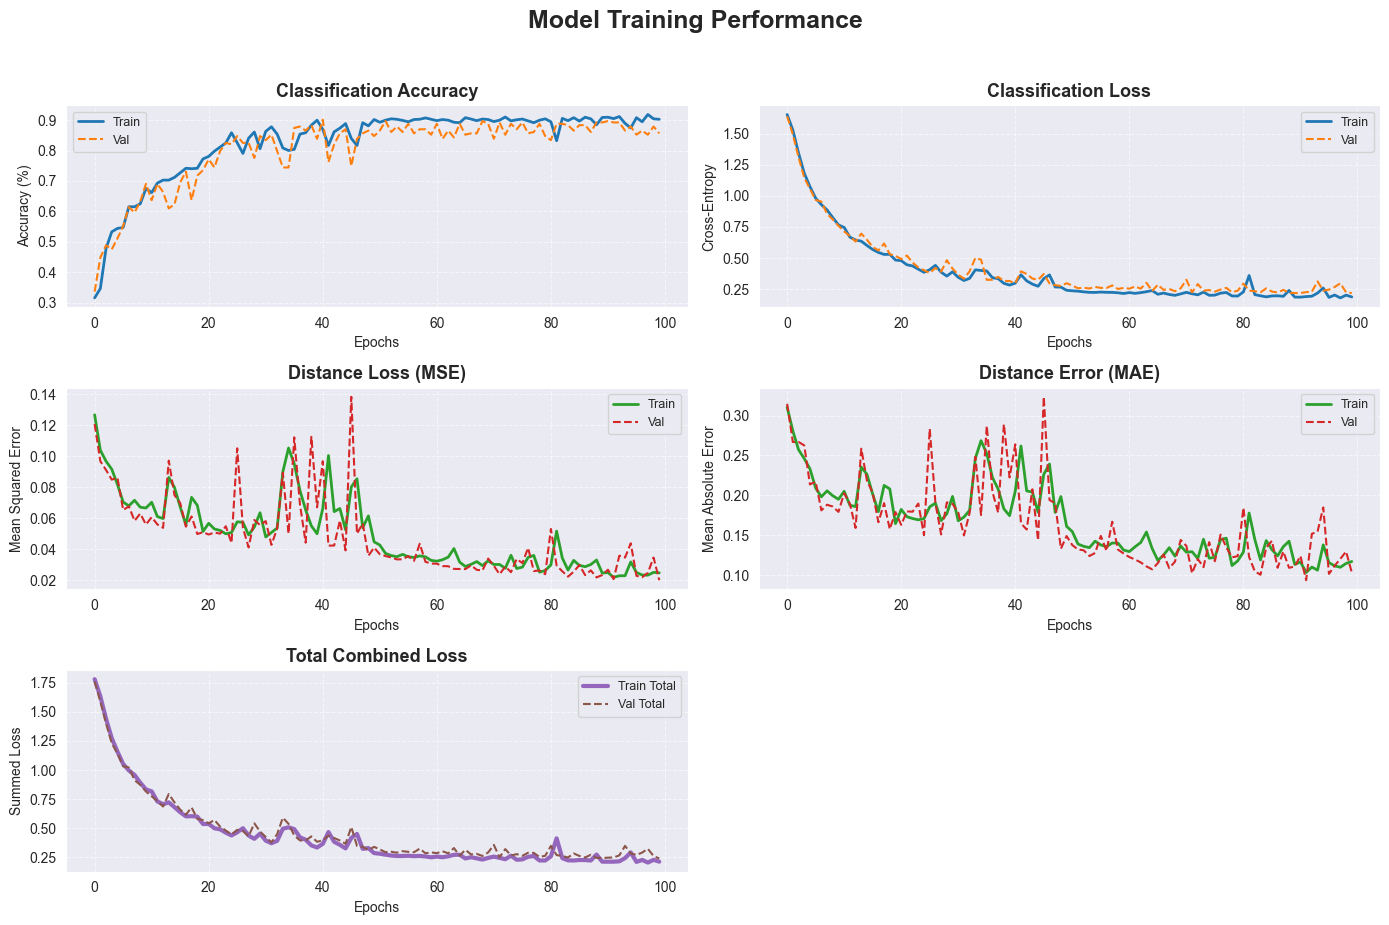

In [197]:
# 1. Increase figure size for 5 subplots
fig = plt.figure(figsize=(14, 10))
plt.suptitle("Model Training Performance", fontsize=18, fontweight='bold', y=0.95)

# Helper function to style each subplot consistently
def style_plot(title, ylabel):
    plt.title(title, fontsize=13, fontweight='semibold')
    plt.xlabel("Epochs", fontsize=10)
    plt.ylabel(ylabel, fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(frameon=True, fontsize=9)

# --- 1. Type Accuracy ---
plt.subplot(3, 2, 1)
plt.plot(history.history["type_accuracy"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_accuracy"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Accuracy", "Accuracy (%)")

# --- 2. Type Loss ---
plt.subplot(3, 2, 2)
plt.plot(history.history["type_loss"], label='Train', color='#1f77b4', linewidth=2)
plt.plot(history.history["val_type_loss"], label='Val', color='#ff7f0e', linestyle='--')
style_plot("Classification Loss", "Cross-Entropy")

# --- 3. Distance Loss (MSE) ---
plt.subplot(3, 2, 3)
plt.plot(history.history["distance_loss"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_loss"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Loss (MSE)", "Mean Squared Error")

# --- 4. Distance MAE ---
plt.subplot(3, 2, 4)
plt.plot(history.history["distance_mae"], label='Train', color='#2ca02c', linewidth=2)
plt.plot(history.history["val_distance_mae"], label='Val', color='#d62728', linestyle='--')
style_plot("Distance Error (MAE)", "Mean Absolute Error")

# --- 5. Total Combined Loss ---
plt.subplot(3, 2, 5)
plt.plot(history.history["loss"], label='Train Total', color='#9467bd', linewidth=3)
plt.plot(history.history["val_loss"], label='Val Total', color='#8c564b', linestyle='--')
style_plot("Total Combined Loss", "Summed Loss")

# 2. Prevent overlapping labels
plt.tight_layout(rect=[0, 0.03, 1, 0.93]) 
plt.show()

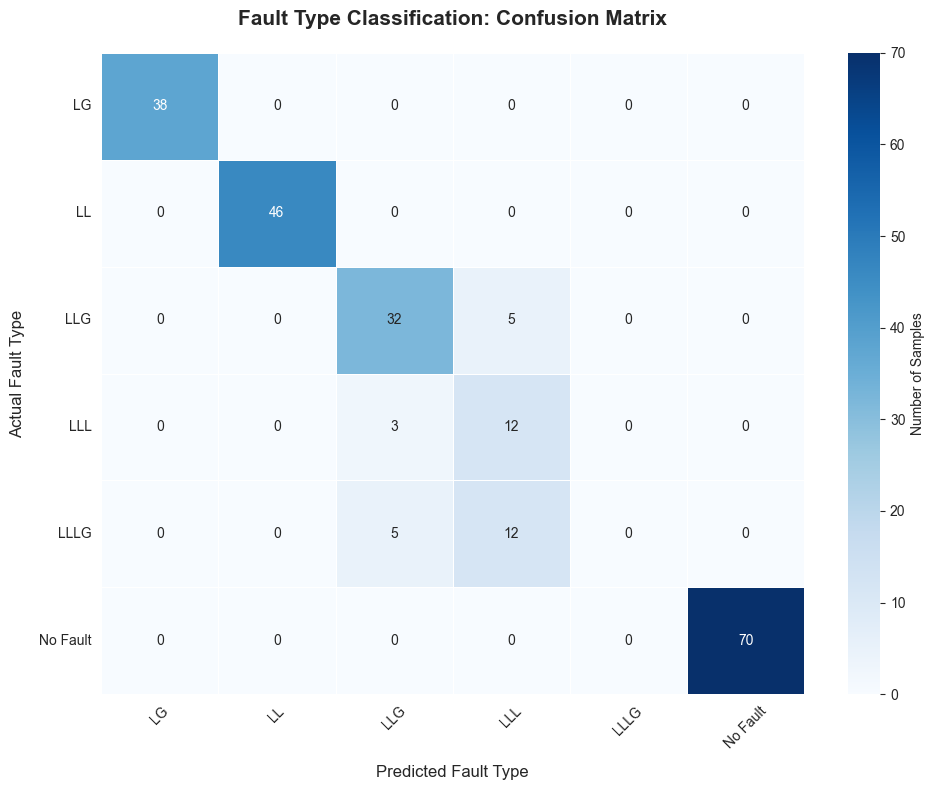

In [198]:
# 1. Define your labels (Make sure the order matches your categorical encoding)
target_names = ['LG', 'LL', 'LLG', 'LLL', 'LLLG', 'No Fault']

# 2. Generate the matrix
cf_matrix = confusion_matrix(np.argmax(y_test_final[:, :6], axis=1), np.argmax(y_pred_probs, axis=1))

# 3. Plotting
plt.figure(figsize=(10, 8))

# Use a cleaner color map ('YlGnBu' or 'Blues') and add a line width for grid effect
sns.heatmap(cf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names,linewidths=.5, cbar_kws={'label': 'Number of Samples'})

plt.title("Fault Type Classification: Confusion Matrix", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Predicted Fault Type", fontsize=12, labelpad=10)
plt.ylabel("Actual Fault Type", fontsize=12, labelpad=10)

# Rotate tick labels for better readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

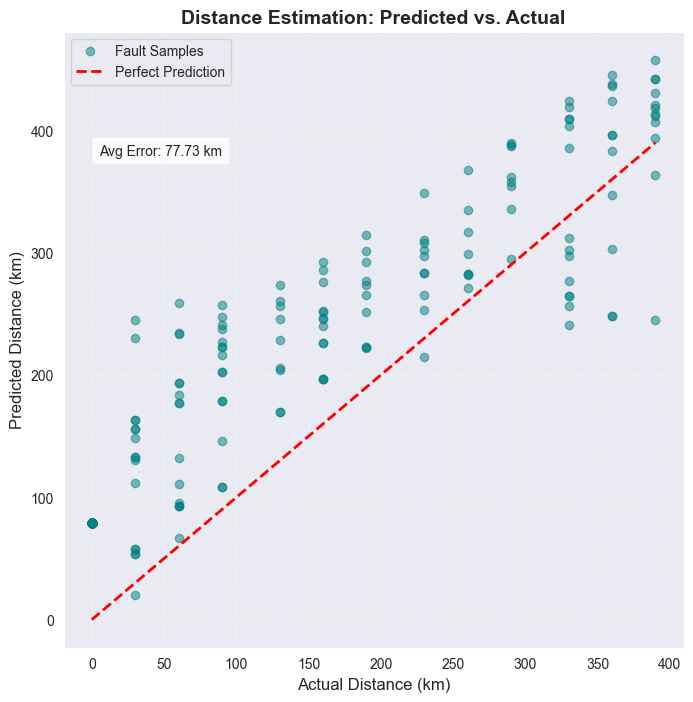

In [ ]:
# 1. Create the plot
plt.figure(figsize=(8, 8))

# 2. Scatter plot of Actual vs Predicted
plt.scatter(y_test_dist_km, y_pred_dist_km, alpha=0.5, color='teal', label='Fault Samples')

# 3. The "Perfect Prediction" Line
# We draw a line from the min distance to the max distance
limits = [np.min(y_test_dist_km), np.max(y_test_dist_km)]
plt.plot(limits, limits, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title("Distance Estimation: Predicted vs. Actual", fontsize=14, fontweight='bold')
plt.xlabel("Actual Distance (km)", fontsize=12)
plt.ylabel("Predicted Distance (km)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()

# 4. Add a text box with the MAE
mae_km = mean_absolute_error(y_test_dist_km, y_pred_dist_km)
plt.text(limits[0]+5, limits[1]-10, f'Avg Error: {mae_km:.2f} km', bbox=dict(facecolor='white', alpha=0.8))

plt.show()